In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
S = ['High', 'Low', 'Charging'] #States [High -> 0 | Low -> 1 | Charging -> 2]
A = ['Search', 'Wait']#Action [Search -> 0 | Wait -> 1]

n_s = len(S) #number of states
n_a = len(A) #number of actions

In [3]:
P = np.zeros((n_s, n_a, n_s)) #Transition Matrix 3D (3 x 2 x 3)
R = np.zeros((n_s, n_a)) #Reward Matrix 2D (3 x 2)

In [4]:
P[0, 0, 0] = 0.7 # High -> Search -> High
P[0, 0, 1] = 0.3 # High -> Search -> Low

P[0, 1, 0] = 1.0 # High -> Wait -> High

P[1, 0, 0] = 0.4 # Low -> Search -> High
P[1, 0, 1] = 0.6 # Low -> Search -> Low

P[1, 1, 1] = 1.0 # Low -> Wait -> Low

P[2, 1, 0] = 1.0 # Charging -> Wait -> High

In [5]:
R[0, 0] = 4 # High and Search
R[0, 1] = 1 # High and Wait

R[1, 0] = -3 # Low and Search
R[1, 1] = 1 # Low and Wait

R[2, 1] = 0 # Charging and Wait

In [6]:
for s in range(n_s):
    for a in range(n_a):
        print(f"P[{S[s]}, {A[a]}] sum = {P[s, a, :].sum()}")

print("\nReward Matrix R : " )
print(R)

#Till here same as in Task - 01

P[High, Search] sum = 1.0
P[High, Wait] sum = 1.0
P[Low, Search] sum = 1.0
P[Low, Wait] sum = 1.0
P[Charging, Search] sum = 0.0
P[Charging, Wait] sum = 1.0

Reward Matrix R : 
[[ 4.  1.]
 [-3.  1.]
 [ 0.  0.]]


**Value Iteration Function**

In [9]:
def value_iteration(P, R, g = 0.9, t = 1e-6):
    n_s = P.shape[0] # or len(S)
    n_a = P.shape[1] # or len(A)
    V = np.zeros(n_s)
    hist = []
    iter = 0

    while True:
        new_V = np.zeros(n_s)
        delta = 0

        for s in range(n_s):
            Q_values = []
            for a in range(n_a):
                q = 0
                for s_next in range(n_s):
                    prob = P[s, a, s_next]
                    q += prob * (R[s, a] + g*V[s_next])
                Q_values.append(q)
            
            new_V[s] = max(Q_values)
            delta = max(delta, abs(new_V[s] - V[s]))
        
        V = new_V
        hist.append(V.copy())
        iter += 1

        if delta < t:
            break
    
    print(f"Value Iteration Converged in {iter} iterations")
    return V, hist

**Finding Optimal Value Function**

In [10]:
V_star, hist = value_iteration(P, R)

print("Optimal Value Function V : ")
for i in range(len(S)):
    print(f"V*({S[i]}) = {V_star[i]:.4f}")

Value Iteration Converged in 133 iterations
Optimal Value Function V : 
V*(High) = 18.1081
V*(Low) = 10.0000
V*(Charging) = 16.2973


**Extracting Optimal Policy**

In [11]:
def extract_policy(P, V, R, g = 0.9):
    n_s = P.shape[0]
    n_a = P.shape[1]

    policy = np.zeros(n_s, dtype = int)

    for s in range(n_s):
        Q_v = []
        for a  in range(n_a):
            q = 0
            for s_next in range(n_s):
                prob = P[s, a, s_next]
                q += prob * (R[s, a] + g*V[s_next])
            Q_v.append(q)
        policy[s] = np.argmax(Q_v)
    return policy

**Optimal Policy**

In [13]:
optimal_p = extract_policy(P, V_star, R)

print("Optimal policy π* is : ")
for i in range(len(S)):
    print(f"{S[i]} -> {A[optimal_p[i]]}")

Optimal policy π* is : 
High -> Search
Low -> Wait
Charging -> Wait


**Plot**

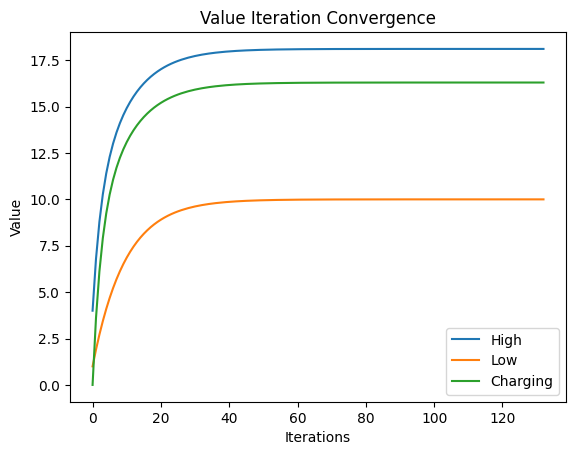

In [14]:
hist = np.array(hist)

for i in range(len(S)):
    plt.plot(hist[:, i], label = S[i])

plt.xlabel("Iterations")
plt.ylabel("Value")
plt.title("Value Iteration Convergence")
plt.legend()
plt.show()